# PyTorch `nn.Module` — Complete Walkthrough

Covers:
1. Model definition
2. Data loading & preprocessing
3. Architecture variants
4. Training loop
5. Evaluation & visualization

## 1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 2. Data Loading & Preprocessing

We wrap a sklearn synthetic dataset inside a custom `Dataset` so PyTorch's `DataLoader` can batch and shuffle it automatically.

In [2]:
# ── 2a. Generate a synthetic binary-classification dataset ─────────────────
X_raw, y_raw = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=4,
    n_redundant=1,
    random_state=42
)

# ── 2b. Standardise features (zero mean, unit variance) ─────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f'X shape : {X_scaled.shape}')  # (1000, 5)
print(f'y shape : {y_raw.shape}')     # (1000,)
print(f'Class balance: {np.bincount(y_raw)}')

X shape : (1000, 5)
y shape : (1000,)
Class balance: [502 498]


In [3]:
# ── 2c. Custom Dataset ───────────────────────────────────────────────────────
class BinaryDataset(Dataset):
    """Wraps numpy arrays into a torch Dataset."""

    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # (N,1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


full_dataset = BinaryDataset(X_scaled, y_raw)

# ── 2d. Train / Val / Test split (70 / 15 / 15) ─────────────────────────────
n_total  = len(full_dataset)
n_train  = int(0.70 * n_total)
n_val    = int(0.15 * n_total)
n_test   = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(full_dataset, [n_train, n_val, n_test])

# ── 2e. DataLoaders ──────────────────────────────────────────────────────────
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

# peek at one batch
Xb, yb = next(iter(train_loader))
print(f'\nBatch shapes — X: {Xb.shape}, y: {yb.shape}')

Train batches : 22
Val   batches : 5
Test  batches : 5

Batch shapes — X: torch.Size([32, 5]), y: torch.Size([32, 1])


## 3. Model Definitions

Three architectures of increasing complexity for the same task.

In [4]:
# ── 3a. Original simple model (from starter notebook) ───────────────────────
class SimpleModel(nn.Module):
    """5 → 3 → 1  (original)"""

    def __init__(self, num_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 3),
            nn.ReLU(),
            nn.Linear(3, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# ── 3b. Deeper model with Batch Normalisation & Dropout ─────────────────────
class DeepModel(nn.Module):
    """5 → 64 → 32 → 16 → 1  with BN + Dropout"""

    def __init__(self, num_features, dropout_p=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# ── 3c. Residual / skip-connection block variant ─────────────────────────────
class ResidualBlock(nn.Module):
    """Single residual block: output = F(x) + x  (requires same dim in/out)"""

    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.block(x) + x)   # skip connection


class ResNetModel(nn.Module):
    """5 → 32 → [ResBlock × 2] → 1"""

    def __init__(self, num_features):
        super().__init__()
        self.input_proj = nn.Linear(num_features, 32)
        self.res_blocks = nn.Sequential(
            ResidualBlock(32),
            ResidualBlock(32)
        )
        self.head = nn.Sequential(
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = torch.relu(self.input_proj(x))
        x = self.res_blocks(x)
        return self.head(x)


# ── Quick sanity-check all three ─────────────────────────────────────────────
NUM_FEATURES = 5
dummy = torch.rand(4, NUM_FEATURES)

for name, model in [('SimpleModel', SimpleModel(NUM_FEATURES)),
                     ('DeepModel',  DeepModel(NUM_FEATURES)),
                     ('ResNetModel', ResNetModel(NUM_FEATURES))]:
    out = model(dummy)
    total_params = sum(p.numel() for p in model.parameters())
    print(f'{name:15s}  output: {out.shape}  params: {total_params}')

SimpleModel      output: torch.Size([4, 1])  params: 22
DeepModel        output: torch.Size([4, 1])  params: 3201
ResNetModel      output: torch.Size([4, 1])  params: 4705


In [5]:
# ── 3d. torchinfo summary for DeepModel ──────────────────────────────────────
!pip install -q torchinfo
from torchinfo import summary

summary(DeepModel(NUM_FEATURES), input_size=(BATCH_SIZE, NUM_FEATURES))

Layer (type:depth-idx)                   Output Shape              Param #
DeepModel                                [32, 1]                   --
├─Sequential: 1-1                        [32, 1]                   --
│    └─Linear: 2-1                       [32, 64]                  384
│    └─BatchNorm1d: 2-2                  [32, 64]                  128
│    └─ReLU: 2-3                         [32, 64]                  --
│    └─Dropout: 2-4                      [32, 64]                  --
│    └─Linear: 2-5                       [32, 32]                  2,080
│    └─BatchNorm1d: 2-6                  [32, 32]                  64
│    └─ReLU: 2-7                         [32, 32]                  --
│    └─Dropout: 2-8                      [32, 32]                  --
│    └─Linear: 2-9                       [32, 16]                  528
│    └─ReLU: 2-10                        [32, 16]                  --
│    └─Linear: 2-11                      [32, 1]                   17
│    └─Si

## 4. Training Loop

A reusable `train_model` function that records per-epoch loss and accuracy for both train and validation sets.

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Single training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()             # 1. zero gradients
        preds = model(X_batch)            # 2. forward pass
        loss  = criterion(preds, y_batch) # 3. compute loss
        loss.backward()                   # 4. backpropagation
        optimizer.step()                  # 5. update weights
        total_loss += loss.item() * X_batch.size(0)
        correct    += ((preds >= 0.5) == y_batch).sum().item()
        total      += X_batch.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluation pass (no gradient computation). Returns (avg_loss, accuracy)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        total_loss += loss.item() * X_batch.size(0)
        correct    += ((preds >= 0.5) == y_batch).sum().item()
        total      += X_batch.size(0)
    return total_loss / total, correct / total

def train_model(model, train_loader, val_loader,
                n_epochs=30, lr=1e-3, device=DEVICE):
    """
    Full training loop with:
      - BCELoss  (Binary Cross-Entropy)
      - Adam optimiser
      - ReduceLROnPlateau scheduler
      - Early stopping (patience=7)
    Returns history dict with loss/acc curves.
    """
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}
    best_val_loss  = float('inf')
    patience_count = 0
    PATIENCE       = 7
    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step(va_loss)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{n_epochs} | '
                  f'Train loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | '
                  f'Val   loss: {va_loss:.4f}  acc: {va_acc:.4f}')
        # early stopping
        if va_loss < best_val_loss:
            best_val_loss = va_loss
            patience_count = 0
            torch.save(model.state_dict(), '/tmp/best_model.pt')
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f'\nEarly stopping at epoch {epoch}.')
                break
    # reload best weights
    model.load_state_dict(torch.load('/tmp/best_model.pt'))
    print('\nBest model weights restored.')
    return history

In [10]:
# ── Train DeepModel ───────────────────────────────────────────────────────────
model = DeepModel(NUM_FEATURES).to(DEVICE)

history = train_model(
    model,
    train_loader,
    val_loader,
    n_epochs=50,
    lr=1e-3
)

Epoch   1/50 | Train loss: 0.6667  acc: 0.6529 | Val   loss: 0.6485  acc: 0.7533
Epoch   5/50 | Train loss: 0.3890  acc: 0.8543 | Val   loss: 0.2644  acc: 0.9533
Epoch  10/50 | Train loss: 0.2755  acc: 0.8886 | Val   loss: 0.1803  acc: 0.9533
Epoch  15/50 | Train loss: 0.2629  acc: 0.8900 | Val   loss: 0.1925  acc: 0.9333

Early stopping at epoch 19.

Best model weights restored.


## 5. Evaluation & Visualisation

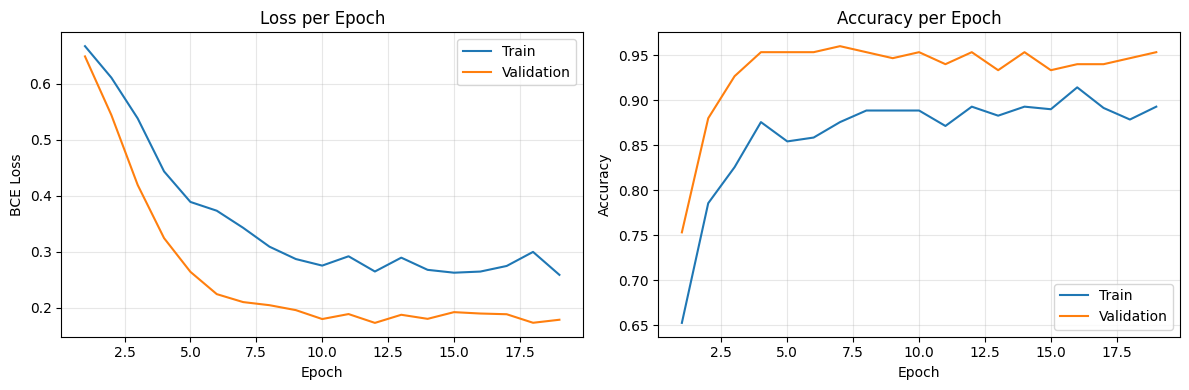

In [11]:
# ── 5a. Loss & Accuracy curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Validation')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['val_acc'],   label='Validation')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# ── 5b. Test-set evaluation ───────────────────────────────────────────────────
criterion = nn.BCELoss()
test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f'Test Loss : {test_loss:.4f}')
print(f'Test Acc  : {test_acc:.4f}')

Test Loss : 0.2099
Test Acc  : 0.9000


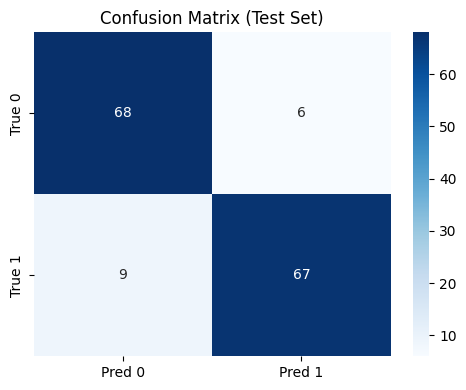


Classification Report:
              precision    recall  f1-score   support

     Class 0       0.88      0.92      0.90        74
     Class 1       0.92      0.88      0.90        76

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150



In [13]:
# ── 5c. Confusion Matrix ─────────────────────────────────────────────────────
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        probs   = model(X_batch).cpu()
        preds   = (probs >= 0.5).int().squeeze()
        labels  = y_batch.int().squeeze()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=['Class 0', 'Class 1']))

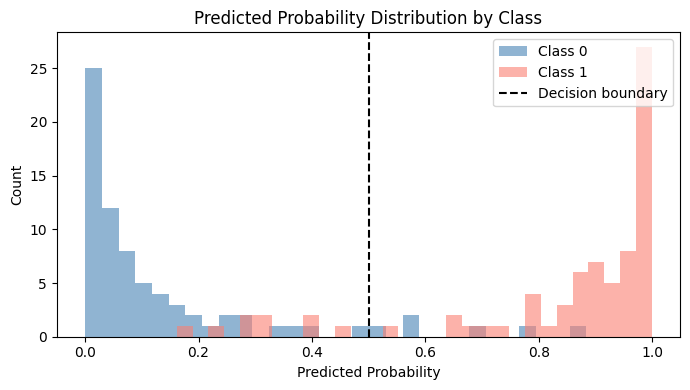

In [16]:
# ── 5d. Predicted probability distribution ───────────────────────────────────
all_probs  = []
all_labels2 = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        probs = model(X_batch.to(DEVICE)).cpu().squeeze().tolist()
        all_probs.extend(probs if isinstance(probs, list) else [probs])
        all_labels2.extend(y_batch.squeeze().tolist())

all_probs   = np.array(all_probs)
all_labels2 = np.array(all_labels2)

plt.figure(figsize=(7, 4))
plt.hist(all_probs[all_labels2 == 0], bins=30, alpha=0.6, label='Class 0', color='steelblue')
plt.hist(all_probs[all_labels2 == 1], bins=30, alpha=0.6, label='Class 1', color='salmon')
plt.axvline(0.5, color='black', linestyle='--', label='Decision boundary')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Predicted Probability Distribution by Class')
plt.legend()
plt.tight_layout()
plt.show()


── Training SimpleModel ──
Epoch   1/50 | Train loss: 0.7113  acc: 0.4786 | Val   loss: 0.6893  acc: 0.5467
Epoch   5/50 | Train loss: 0.6795  acc: 0.5614 | Val   loss: 0.6645  acc: 0.6800
Epoch  10/50 | Train loss: 0.6320  acc: 0.7100 | Val   loss: 0.6313  acc: 0.6933
Epoch  15/50 | Train loss: 0.5943  acc: 0.7186 | Val   loss: 0.6081  acc: 0.7133
Epoch  20/50 | Train loss: 0.5708  acc: 0.7257 | Val   loss: 0.5871  acc: 0.7067
Epoch  25/50 | Train loss: 0.5523  acc: 0.7386 | Val   loss: 0.5657  acc: 0.7467
Epoch  30/50 | Train loss: 0.5354  acc: 0.7457 | Val   loss: 0.5421  acc: 0.7467
Epoch  35/50 | Train loss: 0.5188  acc: 0.7743 | Val   loss: 0.5207  acc: 0.7733
Epoch  40/50 | Train loss: 0.5025  acc: 0.7843 | Val   loss: 0.4999  acc: 0.7933
Epoch  45/50 | Train loss: 0.4864  acc: 0.7929 | Val   loss: 0.4827  acc: 0.8067
Epoch  50/50 | Train loss: 0.4730  acc: 0.8057 | Val   loss: 0.4682  acc: 0.8267

Best model weights restored.
SimpleModel — Test Acc: 0.8133

── Training DeepMod

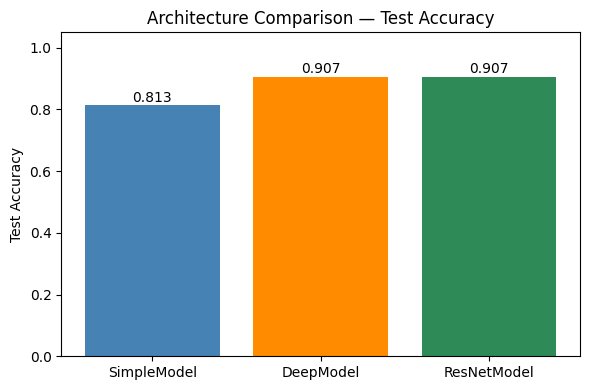

In [17]:
# ── 5e. Compare all three architectures ──────────────────────────────────────
results = {}

for arch_name, arch_cls in [('SimpleModel',  SimpleModel),
                              ('DeepModel',   DeepModel),
                              ('ResNetModel', ResNetModel)]:
    print(f'\n── Training {arch_name} ──')
    m = arch_cls(NUM_FEATURES)
    h = train_model(m, train_loader, val_loader, n_epochs=50, lr=1e-3)
    _, test_acc = evaluate(m, test_loader, nn.BCELoss(), DEVICE)
    results[arch_name] = {'history': h, 'test_acc': test_acc}
    print(f'{arch_name} — Test Acc: {test_acc:.4f}')

# Summary bar chart
names = list(results.keys())
accs  = [results[n]['test_acc'] for n in names]

plt.figure(figsize=(6, 4))
bars = plt.bar(names, accs, color=['steelblue', 'darkorange', 'seagreen'])
plt.ylim(0, 1.05)
plt.ylabel('Test Accuracy')
plt.title('Architecture Comparison — Test Accuracy')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.01,
             f'{acc:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()